# IMPOR LIBRARY
Kode di atas digunakan untuk mengimpor seluruh library yang dibutuhkan dalam proses pengolahan citra digital. `numpy` diimpor sebagai `np` untuk melakukan operasi matematika dan manipulasi array multidimensi yang merepresentasikan piksel citra. `matplotlib.pyplot` diimpor sebagai `plt` untuk menampilkan citra secara visual dan membuat plot histogram distribusi intensitas. `cv2` merupakan library OpenCV yang menyediakan fungsi-fungsi pengolahan citra tingkat lanjut.

In [189]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Membaca Citra

Citra `Meledak.png` dibaca menggunakan `plt.imread()` yang secara otomatis membaca dalam format **RGB** dengan nilai piksel bertipe float dalam rentang **[0.0, 1.0]**.

Alasan menggunakan `plt.imread()`:
- Menghasilkan format RGB yang konsisten untuk ditampilkan langsung dengan `plt.imshow()`
- Tidak perlu konversi channel seperti pada `cv2.imread()` yang menghasilkan format BGR

Hasilnya disimpan dalam variabel `Citra1` sebagai array numpy 3 dimensi (tinggi × lebar × 3 channel).

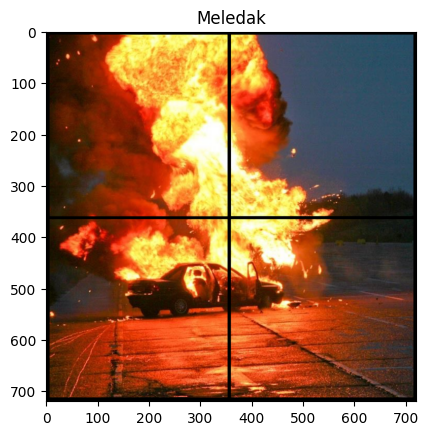

In [190]:
Citra1 = plt.imread("Assets/Meledak.png")

plt.title('Meledak')
plt.imshow(Citra1)

## Slicing

Citra `Meledak.png` dipotong menjadi **4 bagian** menggunakan teknik array slicing numpy.

**Fungsi `slice(gambar, a, b, mode)`:**
- `mode='H'` : memotong secara **horizontal** (baris): `gambar[a:b, :]`
- `mode='V'` : memotong secara **vertikal** (kolom): `gambar[:, a:b]`

**Alasan pemilihan solusi:**
Slicing dipilih karena merupakan cara paling efisien dan langsung untuk memisahkan bagian-bagian citra tanpa mengubah nilai piksel. Setiap bagian dipotong dua kali pertama secara horizontal untuk mendapatkan baris, lalu secara vertikal untuk mendapatkan kolom sehingga menghasilkan 4 kuadran citra.

| Bagian | Baris | Kolom |
|--------|-------|-------|
| p1 (kiri atas) | 10–360 | 10–350 |
| p2 (kanan atas) | 10–360 | 360–710 |
| p3 (kiri bawah) | 367–710 | 10–350 |
| p4 (kanan bawah) | 367–710 | 365–710 |

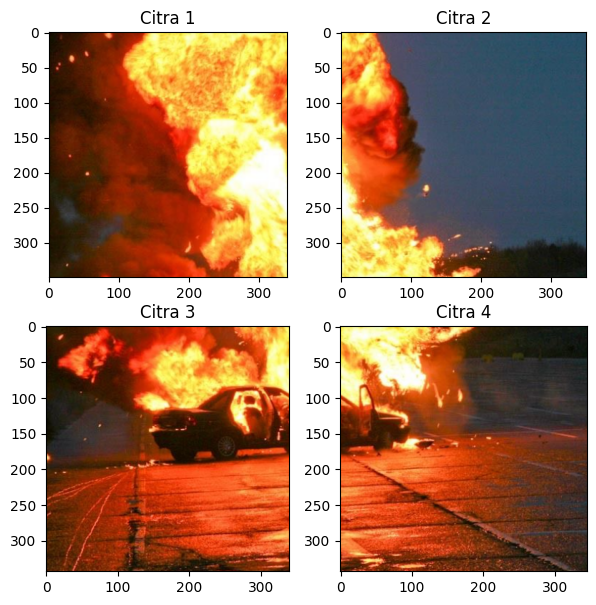

In [191]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

p1_h = slice(Citra1, 10, 360, mode='H')
p1_slice = slice(p1_h, 10, 350, mode='V')

p2_h = slice(Citra1, 10, 360, mode='H')
p2_slice = slice(p2_h, 360, 710, mode='V')

p3_h = slice(Citra1, 367, 710, mode='H')
p3_slice = slice(p3_h, 10, 350, mode='V')

p4_h = slice(Citra1, 367, 710, mode='H')
p4_slice = slice(p4_h, 365, 710, mode='V')

plt.figure(figsize=(7, 7))
plt.subplot(2, 2, 1)
plt.imshow(p1_slice, cmap='gray')
plt.title("Citra 1")


plt.subplot(2, 2, 2)
plt.imshow(p2_slice, cmap='gray')
plt.title("Citra 2")

plt.subplot(2, 2, 3)
plt.imshow(p3_slice, cmap='gray')
plt.title("Citra 3")

plt.subplot(2, 2, 4)
plt.imshow(p4_slice, cmap='gray')
plt.title("Citra 4")

plt.show()

## Merge Citra

Keempat bagian citra digabungkan kembali menggunakan fungsi `merge_image()` hingga membentuk citra utuh seperti semula.

**Fungsi `merge_image(citra1, citra2, orientation)`:**
- `orientation='H'` : menggabungkan secara **horizontal** (bersebelahan kanan-kiri)
- `orientation='V'` : menggabungkan secara **vertikal** (bersebelahan atas-bawah)

**Alasan pemilihan solusi:**
Digunakan `np.zeros()` untuk membuat canvas kosong dengan ukuran yang sesuai, lalu bagian-bagian citra ditempelkan menggunakan slicing. Pendekatan ini mendukung citra grayscale (2D) maupun berwarna (3D) karena ada pengecekan dimensi dengan `len(citra1.shape)`.

**Urutan penggabungan:**
1. `p1 + p2` → `merge1` (horizontal)
2. `p3 + p4` → `merge2` (horizontal)
3. `merge1 + merge2` → `hasil1` (vertikal)

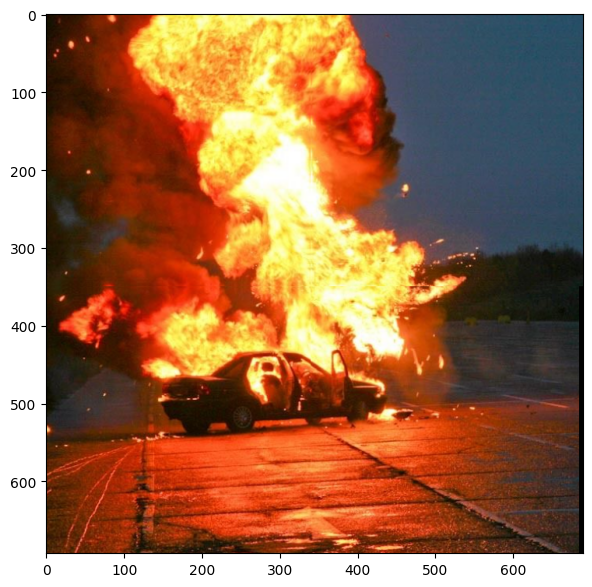

In [192]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], 
citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 
0:citra2.shape[1]] = citra2 
     
    return gabungan

plt.figure(figsize=(7, 7))
merge1 = merge_image(p1_slice, p2_slice, orientation='H')
merge2 = merge_image(p3_slice, p4_slice, orientation='H')
hasil1 = merge_image(merge1, merge2, orientation='V')

plt.imshow(hasil1)
plt.show()

## Konversi ke Grayscale

Citra `hasil1` diubah dari format RGB menjadi **grayscale** menggunakan `cv2.cvtColor()` dengan parameter `cv2.COLOR_BGR2GRAY`.

**Alasan pemilihan solusi:**
Konversi ke grayscale diperlukan agar analisis intensitas piksel menjadi lebih mudah dari 3 channel (R, G, B) menjadi 1 channel nilai intensitas (0–255). Proses ekualisasi dan spesifikasi histogram bekerja pada citra grayscale karena histogram intensitas hanya relevan untuk satu channel.

Hasil disimpan dalam `hasil1_gray` sebagai array 2 dimensi (tinggi × lebar).

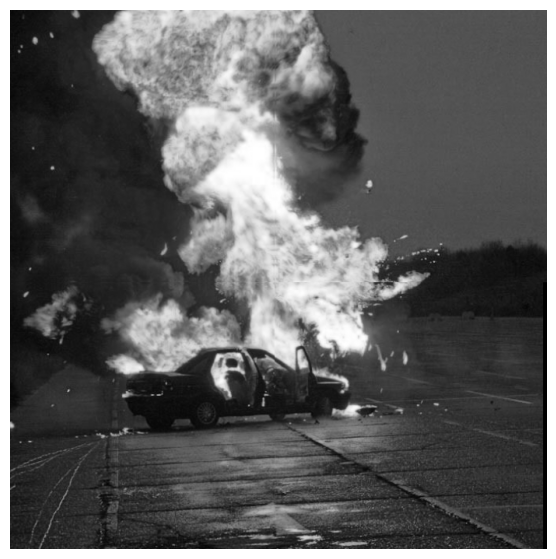

In [193]:
hasil1_gray = cv2.cvtColor(hasil1, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(7, 7))
plt.imshow(hasil1_gray, cmap='gray')
plt.axis('off')
plt.show()

## Ekualisasi 

Ekualisasi dilakukan untuk **meratakan distribusi intensitas piksel** sehingga kontras citra meningkat dan detail yang sebelumnya tersembunyi menjadi lebih terlihat.

**Fungsi `ekualisasi(citra)`:**
1. **Hitung histogram** : menghitung frekuensi kemunculan setiap nilai intensitas (0–255)
2. **Hitung CDF** (Cumulative Distribution Function) : akumulasi histogram untuk mengetahui distribusi kumulatif piksel
3. **Normalisasi CDF** : dipetakan ke rentang [0, 255] dengan rumus: `CDF × 255 / (H × W)`
4. **Pemetaan piksel** : setiap nilai piksel lama diganti dengan nilai hasil normalisasi CDF

Ekualisasi dipilih karena mampu secara otomatis memperbaiki kontras citra tanpa perlu menentukan parameter secara manual. Implementasi manual (tanpa fungsi bawaan) dilakukan untuk memahami proses matematis di baliknya. Input citra dikonversi ke uint8 dengan `(hasil1_gray * 255).astype(np.uint8)` karena nilai float [0,1] perlu diubah ke integer [0,255] sebelum diproses.

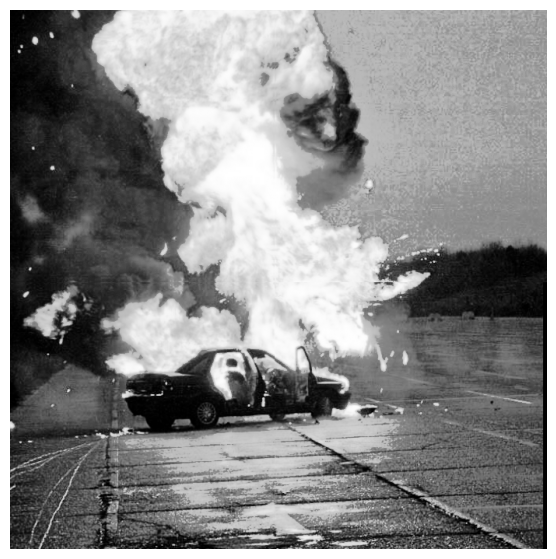

In [194]:
def ekualisasi(citra):
    height, width = citra.shape

    hist = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

hasil_ekualisasi = ekualisasi((hasil1_gray * 255).astype(np.uint8))
plt.figure(figsize=(7, 7))
plt.imshow(hasil_ekualisasi, cmap='gray')
plt.axis('off')
plt.show()

## Fungsi Pembuatan Histogram

Dua fungsi utilitas dibuat untuk memudahkan pembuatan dan penampilan histogram di seluruh proses.

**`buat_hist(citra)`:**
- Menghitung histogram secara manual menggunakan perulangan
- Mengembalikan list berisi 256 elemen, masing-masing mewakili frekuensi intensitas 0–255
- Dapat dipanggil ulang untuk citra apapun

**`plot_histogram(histogram, title, ImgColor)`:**
- Menampilkan histogram dalam bentuk bar chart
- Parameter `ImgColor` memungkinkan warna bar disesuaikan
- Dapat dipanggil ulang untuk berbagai histogram

Dibuat sebagai fungsi terpisah agar dapat digunakan kembali (reusable) di berbagai tahap tanpa mengulang kode yang sama.

In [195]:
def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1
    return histogram

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()

## Menampilkan Histogram Sebelum dan Sesudah Ekualisasi

Histogram sebelum dan sesudah ekualisasi ditampilkan secara bersamaan untuk memudahkan perbandingan distribusi intensitas.

- **Hijau** : histogram sebelum ekualisasi: distribusi terkonsentrasi di rentang tertentu
- **Merah** : histogram sesudah ekualisasi: distribusi lebih menyebar ke seluruh rentang intensitas

Setelah ekualisasi, intensitas piksel yang sebelumnya menumpuk di rentang sempit menjadi tersebar lebih merata di rentang 0–255. Hal ini membuktikan bahwa ekualisasi berhasil meningkatkan kontras citra.

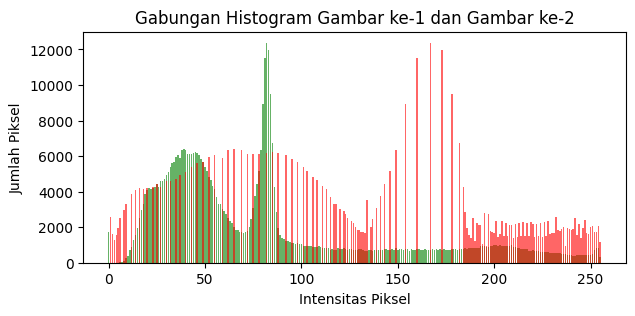

In [196]:
sebelum = buat_hist((hasil1_gray * 255).astype(np.uint8))
sesudah = buat_hist(hasil_ekualisasi)

plt.figure(figsize=(7, 3))
plt.bar(range(256), sebelum, color='green', alpha=0.6, width=0.8)
plt.bar(range(256), sesudah, color='red', alpha=0.6, width=0.8)
plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.show()

## Citra Windut dan Bunga Ireng

Citra `Windut.png` dan `Bunga.png` dibaca menggunakan `plt.imread()`, kemudian dikonversi ke grayscale menggunakan `cv2.cvtColor()` dengan parameter `cv2.COLOR_BGR2GRAY`.

Kedua citra diubah ke grayscale terlebih dahulu karena proses spesifikasi histogram bekerja berdasarkan distribusi intensitas satu channel. Konversi ini memungkinkan perbandingan distribusi intensitas antara citra Windut (objek) dan Bunga (referensi) secara akurat. Kedua citra ditampilkan berdampingan menggunakan `plt.subplot(1, 2, ...)` untuk memudahkan perbandingan visual.

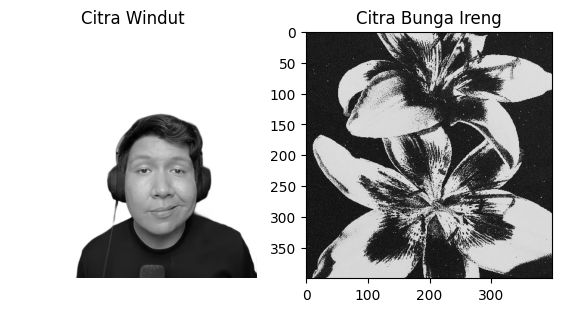

In [197]:
Windut = plt.imread("Assets/Windut.png")
Bunga = plt.imread("Assets/Bunga.png")

Windut_gray = cv2.cvtColor(Windut, cv2.COLOR_BGR2GRAY)
Bunga_gray = cv2.cvtColor(Bunga, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(7, 7))
plt.subplot(1, 2, 1)
plt.imshow(Windut_gray, cmap='gray')
plt.title('Citra Windut')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(Bunga_gray, cmap='gray')
plt.title('Citra Bunga Ireng')

plt.show()

## spesifikasi

Spesifikasi histogram adalah proses menyesuaikan distribusi intensitas citra asal agar menyerupai distribusi intensitas citra target/referensi.

**Langkah-langkah:**
1. **Hitung histogram** masing-masing citra (asal dan target)
2. **Hitung CDF** kedua citra dan normalisasi ke [0, 1]
3. **Buat peta (mapping):** untuk setiap nilai intensitas di citra asal, cari nilai intensitas di citra target yang memiliki CDF paling mendekati → menggunakan `np.argmin(np.abs(cdf_target - cdf_asal[i]))`
4. **Terapkan peta** ke seluruh piksel citra asal

Spesifikasi histogram dipilih karena lebih fleksibel dibanding ekualisasi hasil akhirnya dapat diarahkan sesuai karakteristik citra referensi, bukan sekadar meratakan distribusi. Ini berguna untuk menyamakan antara dua citra yang berbeda.

In [198]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        diff = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(diff)

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil

## Spesifikasi Windut Menggunakan Referensi Bunga Ireng

Fungsi `spesifikasi_histogram()` diterapkan pada citra Windut dengan citra Bunga sebagai referensi.

Hasil spesifikasi membuat distribusi intensitas citra Windut menyerupai citra Bunga Ireng yang didominasi intensitas gelap (hitam). Akibatnya, citra Windut menjadi lebih gelap wajah Windut tampak seperti siluet hitam karena distribusi bunga ireng sangat condong ke nilai intensitas rendah.

Input dikonversi ke uint8: `(Windut_gray * 255).astype(np.uint8)` karena nilai float perlu diubah ke integer [0–255] sebelum diproses oleh fungsi spesifikasi.

(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

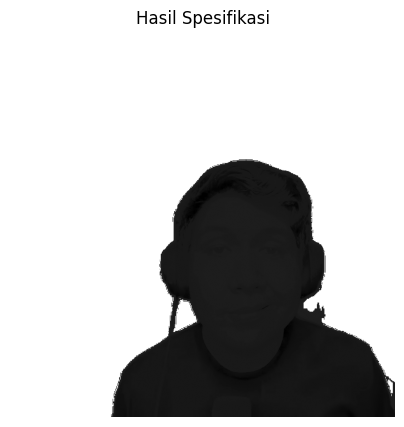

In [199]:
windut_spesifikasi = spesifikasi_histogram((Windut_gray * 255).astype(np.uint8), (Bunga_gray * 255).astype(np.uint8))
plt.figure(figsize=(5, 5))
plt.imshow(windut_spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.axis('off')

## Histogram Hasil Spesifikasi Windut dengan Bunga

Histogram hasil spesifikasi ditampilkan untuk memverifikasi bahwa distribusi intensitas citra Windut telah berhasil disesuaikan dengan citra Bunga Ireng. Terlihat bahwa sebagian besar piksel terkonsentrasi di intensitas tinggi (mendekati 255), yang menunjukkan citra didominasi warna putih konsisten dengan hasil visual berupa siluet hitam di atas area terang.

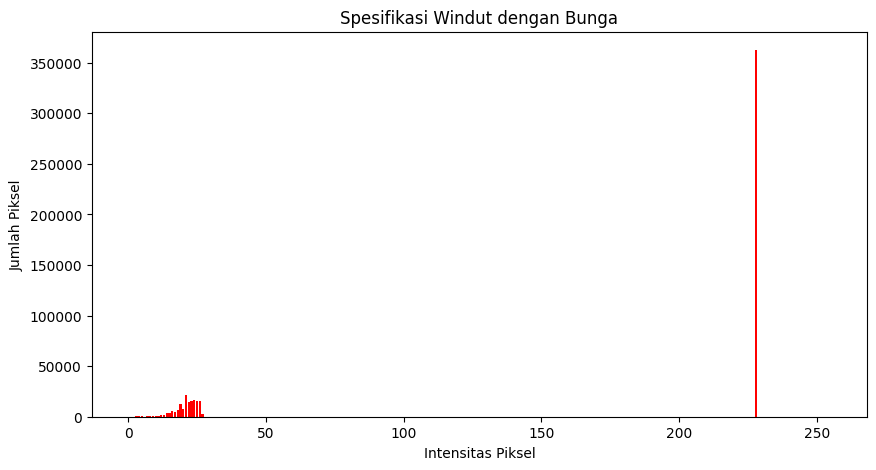

In [200]:
hist_spesifikasi = buat_hist(windut_spesifikasi)

plt.figure(figsize=(10, 5))
plt.bar(range(256), hist_spesifikasi, color='red', width=0.8)
plt.title('Spesifikasi Windut dengan Bunga')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.show()

## Masking

Proses masking dilakukan untuk menggabungkan citra Windut (hasil spesifikasi) dengan citra Meledak (hasil ekualisasi) berdasarkan nilai intensitas piksel.

**Langkah-langkah:**
1. **Crop** kedua citra ke dimensi terkecil menggunakan slicing `[0:h, 0:w]` tanpa fungsi resize
2. **Masking** per piksel:
   - Jika `windut_crop[i,j] < 120` : piksel **gelap** (Windut) : menjadi hitam 
   - Jika `windut_crop[i,j] >= 120` : piksel **terang** (background) : diganti piksel dari citra Meledak

Threshold 120 dipilih sebagai batas antara area gelap (Windut) dan area terang (background putih hasil spesifikasi). Nilai piksel dipaksa ke 0 (bukan nilai aslinya) agar windut berwarna hitam.

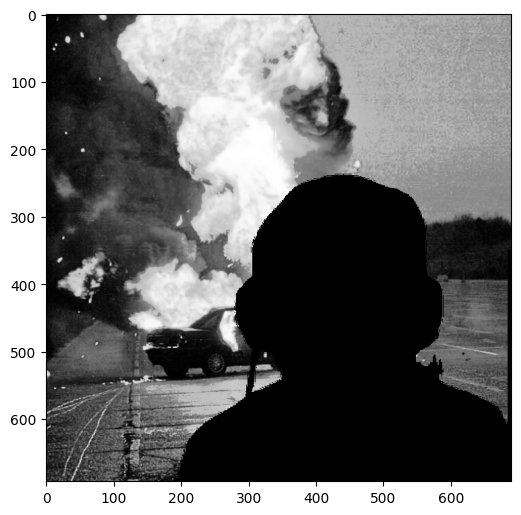

In [201]:
h = min(hasil_ekualisasi.shape[0], windut_spesifikasi.shape[0])
w = min(hasil_ekualisasi.shape[1], windut_spesifikasi.shape[1])

meledak_crop = hasil_ekualisasi[0:h, 0:w]
windut_crop = windut_spesifikasi[0:h, 0:w]

masking = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        if windut_crop[i, j] < 120:
            masking[i, j] = 0  
        else:
            masking[i, j] = meledak_crop[i, j]

plt.figure(figsize=(6, 8))
plt.imshow(masking, cmap='gray')
plt.show()

## Penggabungan Citra Windut dan Meledak

Citra Windut (grayscale asli) digabungkan dengan citra ledakan (hasil ekualisasi) dengan cara mengganti piksel background putih Windut menggunakan piksel dari citra Meledak.

**Langkah-langkah:**
1. **Crop** ke dimensi terkecil menggunakan slicing
2. **Penggabungan per piksel:**
   - Jika `Windut_gray[i,j] > 0.95` : piksel mendekati **putih murni** (background) : ambil dari citra Meledak
   - Selain itu : pertahankan piksel Windut (`Windut_gray[i,j] * 255`)

Threshold `0.95` (bukan `0.8`) dipilih untuk memastikan hanya background putih murni yang terganti.

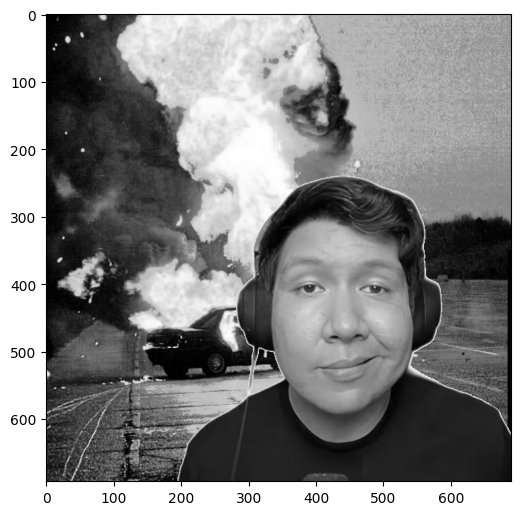

In [202]:
h = min(hasil_ekualisasi.shape[0], Windut_gray.shape[0])
w = min(hasil_ekualisasi.shape[1], Windut_gray.shape[1])

hasil_gabung = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        if Windut_gray[i, j] > 0.95:  
            hasil_gabung[i, j] = hasil_ekualisasi[i, j]
        else:
            hasil_gabung[i, j] = Windut_gray[i, j] * 255

plt.figure(figsize=(6, 8))
plt.imshow(hasil_gabung, cmap='gray')
plt.show()

## Spesifikasi Windut dengan Referensi Langit

Sebagai tahap penyempurnaan, citra hasil gabungan (`hasil_gabung`) dikenai spesifikasi histogram menggunakan citra langit sebagai referensi.

**Langkah-langkah:**
1. Baca `Langit.png` menggunakan `plt.imread()` 
2. Konversi ke uint8: `(Langit * 255).astype(np.uint8)[:, :, :3]`
3. Konversi ke grayscale: `cv2.cvtColor(..., cv2.COLOR_RGB2GRAY)`
4. Terapkan `spesifikasi_histogram(hasil_gabung, Langit_gray)`

Spesifikasi dengan citra langit membuat pencahayaan dan kontras hasil gabungan menjadi lebih seimbang dan natural, karena distribusi intensitas citra langit lebih merata dibanding citra ledakan yang kontrasnya ekstrem.

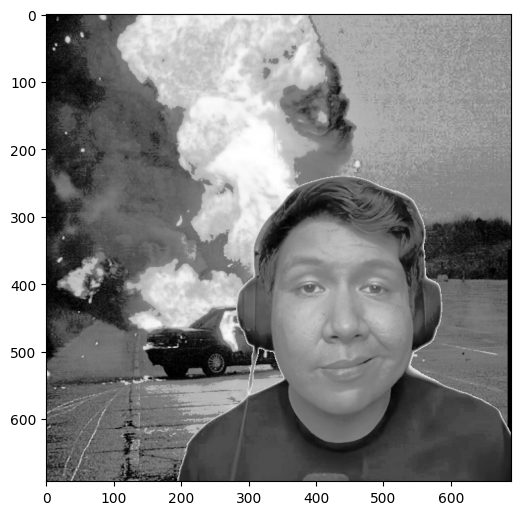

In [203]:
Langit = plt.imread("Assets/Langit.png")
Langit_gray = cv2.cvtColor((Langit * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
spesifikasi_windutlangit = spesifikasi_histogram(hasil_gabung, Langit_gray)

plt.figure(figsize=(6, 8))
plt.imshow(spesifikasi_windutlangit, cmap='gray')
plt.show()

## Histogram Hasil Spesifikasi Windut dengan Langit

Histogram hasil spesifikasi akhir ditampilkan untuk memverifikasi perubahan distribusi intensitas setelah menggunakan citra langit sebagai referensi. Dibandingkan histogram spesifikasi sebelumnya (dengan bunga), distribusi intensitas kini lebih tersebar di rentang menengah hingga tinggi mencerminkan karakteristik citra langit yang cerah dan merata. Hasilnya membuat citra Windut terlihat lebih natural dan menyatu dengan background ledakan.

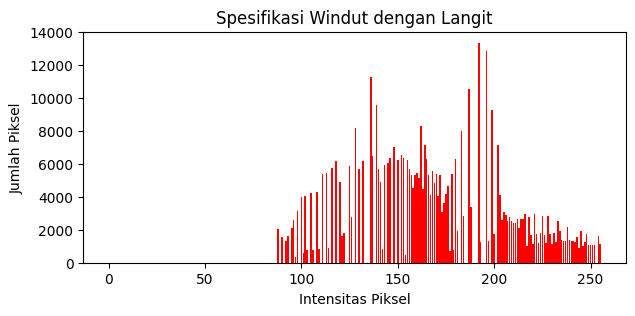

In [204]:
hist_windutlangit = buat_hist(spesifikasi_windutlangit)

plt.figure(figsize=(7, 3))
plt.bar(range(256), hist_windutlangit, color='red', width=0.8)
plt.title('Spesifikasi Windut dengan Langit')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.show()

## Windut dan Background Berwarna

Tahap terakhir adalah menghasilkan citra gabungan **berwarna** antara Windut dan background Meledak, menghasilkan citra Windut dan Meledak yang berwarna.

**Langkah-langkah:**
1. **Background (`BG`):** `hasil1` dikonversi dari RGB → BGR menggunakan `cv2.COLOR_BGR2RGB`, sehingga channel merah dan biru tertukar : ledakan oranye tampil sebagai **biru**
2. **Objek (`WD`):** Windut dibaca dengan `cv2.imread()` yang menghasilkan format **BGR** : warna tampil kebiruan
3. **Crop:** kedua citra dipotong ke dimensi terkecil menggunakan slicing
4. **Penggabungan per piksel:**
   - `np.mean(WD[i,j]) > 220` : rata-rata channel tinggi (terang)
   - `max(r,g,b) - min(r,g,b) < 30` : selisih channel kecil = **putih sejati** (bukan highlight kulit)
   - Jika keduanya terpenuhi maka ambil piksel background ledakan
   - Selain itu pertahankan piksel Windut

Dua kondisi masking digunakan agar hanya piksel background putih murni yang terganti. Efek warna biru terjadi secara alami akibat perbedaan format channel antara `plt.imread()` (RGB) dan `cv2.imread()` (BGR).

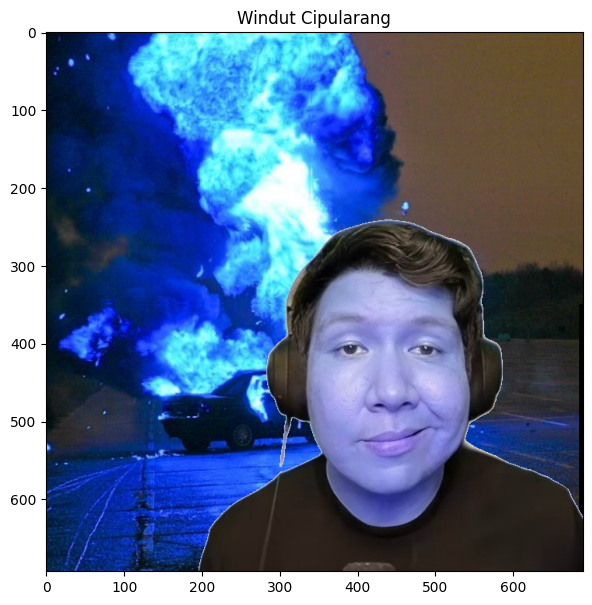

In [ ]:
BG = cv2.cvtColor((hasil1 * 255).astype(np.uint8)[:, :, :3], cv2.COLOR_BGR2RGB)
WD = cv2.imread('Assets/Windut.png')

h = min(BG.shape[0], WD.shape[0])
w = min(BG.shape[1], WD.shape[1])
BG, WD = BG[0:h, 0:w], WD[0:h, 0:w]

ubah_warna = np.zeros((h, w, 3), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        r, g, b = WD[i, j, 0], WD[i, j, 1], WD[i, j, 2]
        if np.mean(WD[i, j]) > 220 and (max(r,g,b) - min(r,g,b)) < 30:  # putih murni
            ubah_warna[i, j] = BG[i, j]
        else:
            ubah_warna[i, j] = WD[i, j]

plt.figure(figsize=(7, 7))
plt.imshow(ubah_warna)
plt.title('Windut Cipularang')

plt.show()

## Kesimpulan

Melalui praktikum Modul 2 ini, telah dipelajari dan dipraktikkan berbagai teknik dasar 
pengolahan citra digital secara menyeluruh, mulai dari pembacaan citra, slicing, 
penggabungan, hingga manipulasi intensitas piksel.

**1. Ekualisasi Histogram**
Ekualisasi histogram dilakukan dengan menghitung histogram citra, membangun CDF 
(Cumulative Distribution Function), lalu memetakan nilai intensitas lama ke nilai baru 
menggunakan normalisasi CDF dengan rumus `CDF × 255 / (H × W)`. Hasilnya terbukti 
mampu meningkatkan kontras citra ledakan yang sebelumnya memiliki distribusi intensitas 
menumpuk di rentang sempit menjadi lebih menyebar merata di seluruh rentang 0–255, 
sehingga detail citra yang sebelumnya tersembunyi menjadi lebih terlihat.

**2. Spesifikasi Histogram**
Spesifikasi histogram dilakukan dengan mencocokkan CDF citra asal terhadap CDF citra 
referensi menggunakan pendekatan minimum absolute difference. Teknik ini terbukti lebih 
fleksibel dibanding ekualisasi karena hasil akhirnya dapat diarahkan sesuai 
karakteristik citra referensi. Hal ini dibuktikan melalui dua percobaan: spesifikasi 
Windut dengan Bunga Ireng yang menghasilkan efek siluet gelap, dan spesifikasi dengan 
citra Langit yang membuat pencahayaan citra menjadi lebih natural dan seimbang.